# Задание

В этом задании вы попробуете решить реальную задачу из области анализа данных — предсказание оттока клиентов банка. Банки и компании активно используют машинное обучение, чтобы заранее определить клиентов, которые могут перестать пользоваться их услугами.
Почему это важно? Если компания знает, какие клиенты могут уйти, она может заранее предложить им специальные условия, скидки или улучшенный сервис. Это помогает сохранить клиентов и уменьшить финансовые потери.
В этом задании вы познакомитесь с одной из базовых моделей машинного обучения — логистической регрессией, которая используется для задач бинарной классификации (предсказания одного из двух классов). Вы научитесь подготавливать данные, обучать модель и интерпретировать её результаты.

## Описание задания
Вам необходимо построить модель машинного обучения, которая будет предсказывать вероятность ухода клиента из банка.
У вас есть датасет с информацией о клиентах банка, в нём содержатся такие признаки, как:

- кредитный рейтинг клиента
- страна проживания
- пол
- возраст
- срок обслуживания в банке
- баланс на счёте
- количество банковских продуктов
- наличие кредитной карты
- активность клиента
- примерная зарплата

Целевая переменная называется churn:
- 1 — клиент ушёл из банка
- 0 — клиент остался

Ваша задача — используя эти данные:
1. Провести первичный анализ данных
2. Подготовить данные для обучения модели
3. Обучить модель логистической регрессии, либо иную модель классификации
4. Оценить качество модели
5. Проанализировать влияние признаков на предсказание оттока
Дополнительно можно сравнить логистическую регрессию с другой моделью классификации (например, Random Forest).


(*)являются дополнительным требованием и выполняются по желанию студента, не влияют на получение зачета, но служат дополнительной практикой.

Библиотеки Python:
- pandas
- matplotlib
- seaborn
- scikit-learn

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Инструкция к выполнению

### Шаг 1. Загрузка данных
Загрузите датасет в Python с помощью библиотеки pandas.

Необходимо:

● посмотреть первые строки таблицы

● определить размер датасета

● проверить названия колонок

● убедиться, что целевая переменная загружена корректно.

In [35]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')
display(df.head(5))
display(df.columns)
display(df['churn'].value_counts())
df.shape

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

churn
0    7963
1    2037
Name: count, dtype: int64

(10000, 12)

### Шаг 2. Первичный анализ данных

Проведите базовый анализ данных.

Необходимо:

● посмотреть типы данных (info())

● изучить статистику числовых признаков (describe())

● проверить распределение целевой переменной

● проверить наличие пропущенных значений

● проверить наличие дубликатов

In [36]:
df.info()
display(df.describe())
display(df.isna().sum())
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

np.int64(0)

### Шаг 3. Разведочный анализ данных (EDA)
Изучите распределение признаков и их связь с оттоком клиентов.

Постройте:

● график распределения целевой переменной

● гистограммы числовых признаков

● * boxplot для возраста и баланса относительно churn

● * корреляционную матрицу признаков

Сделайте краткие выводы: какие признаки могут быть связаны с оттоком клиентов. Пропишите свои выводы в ноутбуке.

array([[<Axes: title={'center': 'credit_score'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'products_number'}>,
        <Axes: title={'center': 'estimated_salary'}>]], dtype=object)

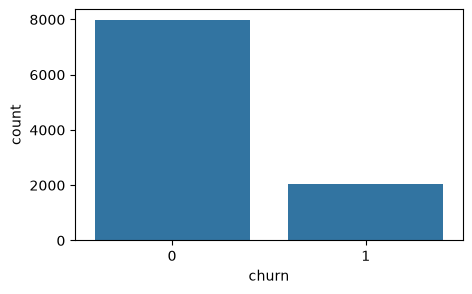

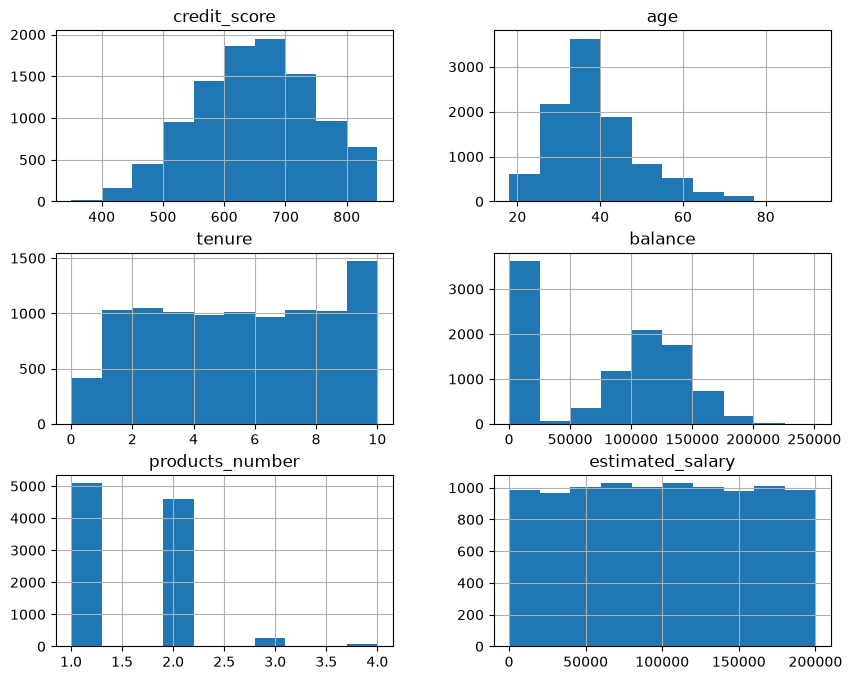

In [37]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df,x='churn')
columns_to_plot = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
df.hist(column=columns_to_plot, figsize=(10, 8))

<Axes: >

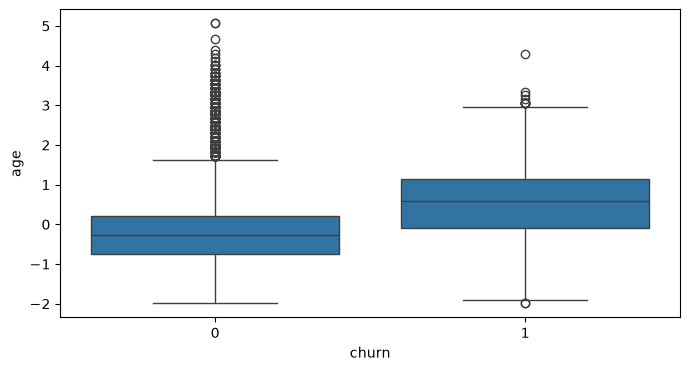

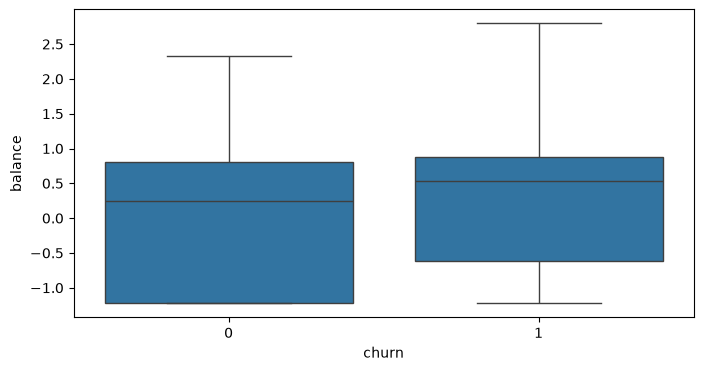

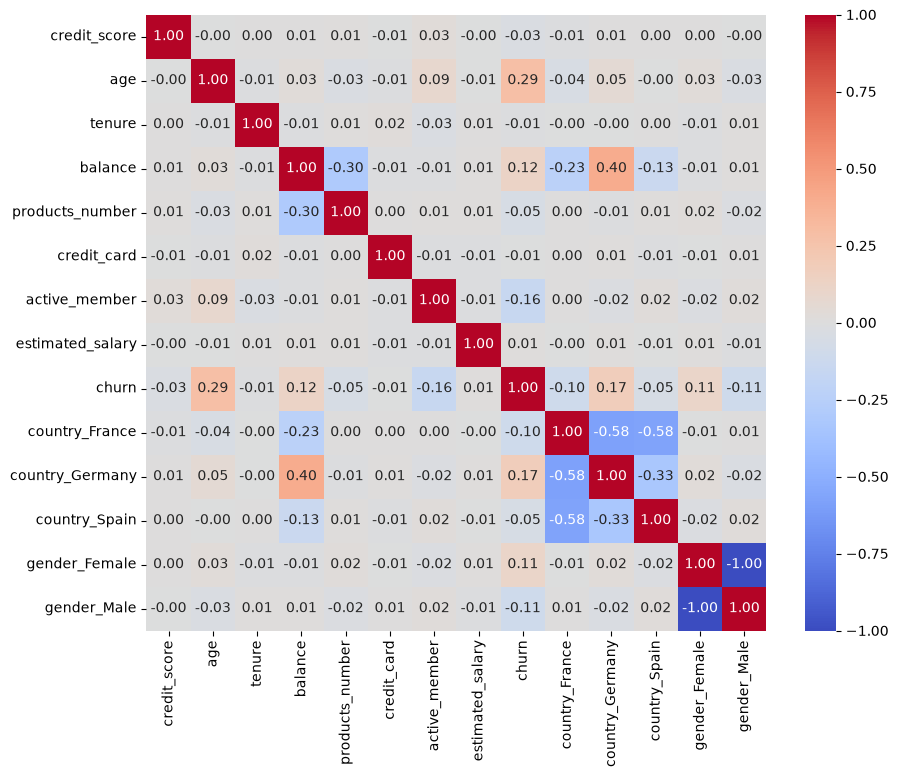

In [44]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='churn', y='age')

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='churn', y='balance')

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

### Выводы по EDA:

Клиенты, ушедшие из банка, в среднем старше - медиана возраста у класса 1 заметно выше.
Разница по balance между классами небольшая, но у ушедших чуть выше медиана баланса.
По корреляционной матрице сильных связей между признаками нет. С churn сильнее всего коррелирует age (положительно) и active_member (отрицательно).

### Шаг 4. Предобработка данных
Подготовьте данные для обучения модели.

Необходимо:

● удалить столбцы, которые вы считаете не нужными для обучения модели. Свой выбор аргументируйте в файле ноутбука

● закодировать категориальные признаки (country, gender) с помощью One-Hot Encoding

● масштабировать числовые признаки с помощью StandardScaler

● сформировать итоговый набор признаков

In [39]:
# удаляем customer_id — это просто идентификатор, он не несёт информации для модели
df = df.drop('customer_id', axis=1)

# One-Hot Encoding категориальных признаков
df = pd.get_dummies(df, columns=['country', 'gender'])

# масштабирование числовых признаков
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
df[num_features] = scaler.fit_transform(df[num_features])

### Шаг 5. Разделение данных
Разделите данные на:

● обучающую выборку (80%)

● тестовую выборку (20%)

Используйте функцию train_test_split

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Шаг 6. Обучение модели
Обучите модель Logistic Regression.

После обучения:

● получите предсказания модели на тестовой выборке

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Шаг 7. Оценка качества модели
Оцените качество модели с помощью следующих метрик:

1. Accuracy
2. Precision
3. *Recall
4. *F1-score
5. *ROC-AUC
6. *Также постройте Confusion Matrix

Accuracy: 0.8115
Precision: 0.5563
Recall: 0.201
F1: 0.2953
ROC-AUC: 0.7789


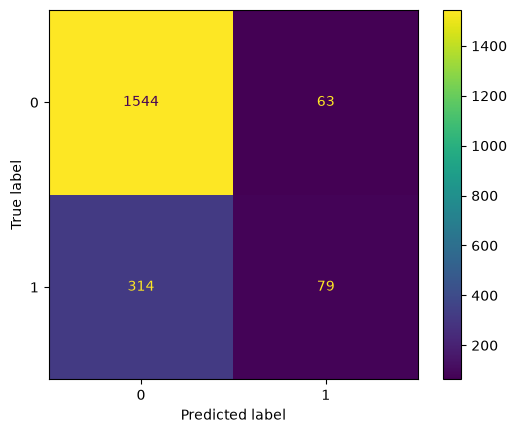

In [42]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, ConfusionMatrixDisplay)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall:', round(recall_score(y_test, y_pred), 4))
print('F1:', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Шаг 8. Интерпретация результатов
Проанализируйте результаты модели.

Необходимо:

● определить наиболее важные признаки

● построить график важности признаков

● сделать вывод, какие факторы сильнее всего влияют на отток клиентов.

<Axes: >

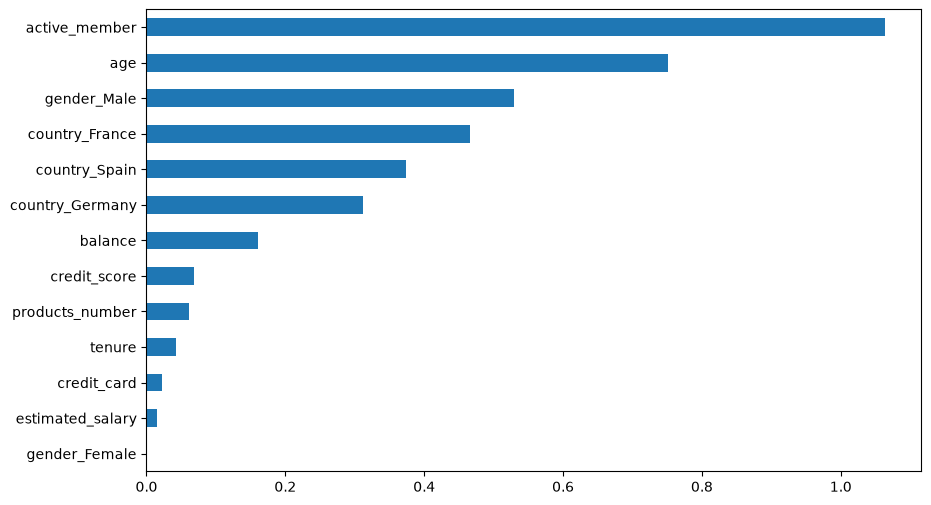

In [43]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.abs().sort_values().plot(kind='barh', figsize=(10, 6))

### Вывод

Наиболее важные признаки: активность клиента (отрицательно - активные клиенты уходят реже), возраст (положительно - старше клиент, выше риск ухода), страна Германия, баланс счёта. Пол оказывает умеренное влияние (мужчины уходят реже). Кредитная карта, зарплата, срок обслуживания и количество продуктов влияют слабо.

### Шаг 9. Итоговые выводы
Сформулируйте краткие выводы:

● насколько хорошо модель предсказывает отток клиентов

● какие признаки оказались наиболее важными

● * какие улучшения можно внести в модель (например, добавить новые признаки или попробовать другие алгоритмы)

### Итог:

- Модель показывает Accuracy 0.81, Precision 0.56, но Recall всего 0.2 - модель пропускает ~80% ушедших клиентов. Причина — дисбаланс классов: 79.6% клиентов остаются. F1 = 0.30, ROC-AUC = 0.78.
- Важнейшие факторы оттока: активность клиента (активные уходят заметно реже), возраст (старше — выше риск), страна Германия, баланс счёта.
- Слабо влияют: зарплата, кредитная карта, срок обслуживания, количество продуктов.
- Улучшения: class_weight='balanced' для борьбы с дисбалансом, Random Forest / Gradient Boosting, настройка порога классификации, новые признаки.